# OpenCDaRR vs BlueSky — how long does the same flight take to simulate?

Both simulators fly the **same** scenario: `N` drones evenly spaced on a 1500 m ring, each heading
for the point diametrically opposite. The run is over when every drone is within 30 m of its target
waypoint. What is measured is **wallclock** — how long the machine took, not how long the flight
took.

This is a compute benchmark, not a validation. It does not tell you whether the two agree on
*trajectories*; that question is ADR 0005's, and `scripts/trajectory_comparison/` is where it lives.
What it does tell you is how each one's cost scales with fleet size, and the two answers turn out to
be very different shapes.

Three things had to be equalised before the numbers meant anything:

- **Integration step.** Both run at `dt = 0.05 s`, BlueSky's default `simdt`.
- **Cruise speed.** Our position tracker chases the waypoint at whatever the envelope allows, so an
  uncapped M600 accelerates to its 18 m/s ceiling while BlueSky holds the commanded 10 m/s — the two
  would be simulating different flights. The envelope is capped at the cruise speed so both fly the
  same 3000 m at the same 10 m/s.
- **Conflict detection on, resolution off, in both.** Otherwise one of them is doing `O(N²)` work the
  other is not.

One thing is deliberately **not** equalised: BlueSky evaluates detection on its own `asas_dt = 1 s`
cadence, while our conflict accumulator calls the detector every step. That is an architectural
difference, and correcting it is a code change rather than a setting — so it is left in, and noted
again at the bottom where it matters.

Running this needs BlueSky, which lives in its own conda environment. The BlueSky half is therefore
written out as a script and run in a subprocess against that interpreter — see *The BlueSky side*
below. Point `CDARR_PYTHON` and `BLUESKY_DIR` at your own install if they differ from the defaults.

The largest fleets are slow to run: at `N = 64` a single pass takes several minutes, so the number of
repetitions is scaled down as the fleet grows.

In [1]:
%matplotlib inline
import contextlib
import dataclasses
import json
import math
import os
import statistics as stats
import subprocess
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr import M600, Agent, StateBased, geo
from opencdarr.autopilot import WaypointAutopilot
from opencdarr.fleet import FleetStreams, build_env
from opencdarr.mission import Mission
from opencdarr.scenario import swap_ring
from opencdarr.state import AircraftState

FLEET_SIZES = [2, 4, 8, 16, 32, 64]
SPEED = 10.0        # cruise speed [m/s]
RADIUS = 1500.0     # ring radius [m] -> 3000 m across the diameter
CAPTURE = 30.0      # "arrived" test: within this many metres of the target waypoint
RPZ = 50.0          # protected zone radius [m]
LOOKAHEAD = 30.0    # detection lookahead [s]
DT = 0.05           # integration step [s] -- BlueSky's default simdt
T_MAX = 900.0       # cap [s]; the crossing takes ~297 s


def reps_for(n: int) -> int:
    """Repetitions at fleet size n. Cost grows as N^2, so the big fleets get fewer passes."""
    return 3 if n <= 8 else 2 if n <= 32 else 1


OUT = Path("_bluesky_comparison")
OUT.mkdir(exist_ok=True)

# where BlueSky lives -- override for a different install
CDARR_PYTHON = Path(os.environ.get(
    "CDARR_PYTHON", Path.home() / "anaconda3" / "envs" / "cdarr" / "bin" / "python"))
BLUESKY_DIR = Path(os.environ.get("BLUESKY_DIR", Path.home() / "Projects" / "bluesky"))
print(f"BlueSky interpreter: {CDARR_PYTHON}  (exists: {CDARR_PYTHON.exists()})")
print(f"BlueSky repo:        {BLUESKY_DIR}  (exists: {BLUESKY_DIR.exists()})")
print(f"fleet sizes {FLEET_SIZES}, repetitions {[reps_for(n) for n in FLEET_SIZES]}")

BlueSky interpreter: /Users/mfrahman/anaconda3/envs/cdarr/bin/python  (exists: True)
BlueSky repo:        /Users/mfrahman/Projects/bluesky  (exists: True)
fleet sizes [2, 4, 8, 16, 32, 64], repetitions [3, 3, 3, 2, 2, 1]


## The scenario, generated once

`swap_ring` places the drones and picks each one's target. Both simulators read the *same* lat/lons
out of the file written here, so the geometry is identical rather than merely equivalent — no chance
of two slightly different rings quietly explaining a timing difference.

Each entry carries where the drone starts, which way it is pointing, how fast it is going, and where
it is headed. That is everything either simulator needs.

In [2]:
scenario = {
    "config": {
        "speed": SPEED, "radius": RADIUS, "capture_m": CAPTURE, "rpz_m": RPZ,
        "t_lookahead": LOOKAHEAD, "dt": DT, "t_max": T_MAX,
        "reps": {str(n): reps_for(n) for n in FLEET_SIZES},
    },
    "fleets": {},
}
for n in FLEET_SIZES:
    scenario["fleets"][str(n)] = [
        {"id": s.id, "lat": s.lat, "lon": s.lon, "trk": s.trk, "gs": s.gs,
         "wp_lat": wp[0], "wp_lon": wp[1]}
        for s, wp in swap_ring(n, speed=SPEED, radius=RADIUS)
    ]

scenario_path = OUT / "scenario.json"
scenario_path.write_text(json.dumps(scenario, indent=1))

for ac in scenario["fleets"]["4"]:
    print(f"{ac['id']}  start ({ac['lat']:.4f}, {ac['lon']:.4f})  trk {ac['trk']:5.1f} deg"
          f"  -> ({ac['wp_lat']:.4f}, {ac['wp_lon']:.4f})")

A0  start (52.0135, 4.0000)  trk 180.0 deg  -> (51.9865, 4.0000)
A1  start (52.0000, 4.0219)  trk 270.0 deg  -> (52.0000, 3.9781)
A2  start (51.9865, 4.0000)  trk   0.0 deg  -> (52.0135, 4.0000)
A3  start (52.0000, 3.9781)  trk  90.0 deg  -> (52.0000, 4.0219)


## Our side

Each drone gets a `WaypointAutopilot` aimed at its target, and `stop_within` ends the run once every
one of them is inside the 30 m capture radius.

The run is driven through the estimator interface — `build_env`, then `advance` until `is_terminal` —
which is exactly the loop `run_fleet` runs, minus the optional states log. Skipping the log matters at
64 drones, where recording every frame would cost hundreds of megabytes and time the recorder rather
than the simulator.

Two settings are worth calling out:

- **`done_timeout=1e9`.** The default stop condition ends a run once the fleet has been clear for a
  while — every pair diverging and separated. In this scenario that happens shortly after the drones
  pass the centre, roughly halfway through the flight, and the run would end long before anyone
  reached a waypoint. Pushing it out of reach leaves `stop_within` as the only thing that stops the
  run, which is the condition being timed.
- **The capped envelope.** `dataclasses.replace(M600, v_max=SPEED, v_min=-SPEED)` is what makes
  "speed" actually the speed, as in `examples/handbook/circle_scenario.ipynb`.

Only the stepping loop is timed — building the fleet and the environment is not.

In [3]:
CAPPED = dataclasses.replace(M600, v_max=SPEED, v_min=-SPEED)


def build_fleet(fleet):
    return [
        Agent(
            AircraftState(id=ac["id"], lat=ac["lat"], lon=ac["lon"],
                          trk=ac["trk"], gs=ac["gs"]),
            CAPPED,
            autopilot=WaypointAutopilot(
                Mission(goto=(ac["wp_lat"], ac["wp_lon"])), capture_radius=CAPTURE),
        )
        for ac in fleet
    ]


def fly_ours(fleet):
    """One timed run. Returns (wallclock [s], sim time [s], steps, terminal state)."""
    agents = build_fleet(fleet)
    env = build_env(
        agents, rpz=RPZ, t_lookahead=LOOKAHEAD, dt=DT,
        detector=StateBased(),      # detection on, resolution off -- matched to BlueSky
        resolver=None, recovery=None,
        t_max=T_MAX,
        done_timeout=1e9,           # only stop_within ends the run
        stop_within=CAPTURE,
    )
    streams = FleetStreams()
    state, steps = env.initial_state(agents), 0
    t0 = time.perf_counter()
    while not env.is_terminal(state):
        state = env.advance(state, streams)
        steps += 1
    return time.perf_counter() - t0, state.t, steps, state


def benchmark(label):
    """Time every fleet size, reps_for(n) times each."""
    rows = []
    for n in FLEET_SIZES:
        for rep in range(reps_for(n)):
            started = datetime.now().astimezone()
            wall, sim_t, steps, _ = fly_ours(scenario["fleets"][str(n)])
            rows.append({"n": n, "rep": rep, "started": started.isoformat(timespec="seconds"),
                         "wallclock_s": wall, "sim_t_s": sim_t, "steps": steps})
            print(f"{label:6} n={n:2d} rep {rep}  sim={sim_t:6.2f}s  wall={wall:8.2f}s  "
                  f"steps={steps}", flush=True)
    return rows


results_ours = benchmark("ours")
(OUT / "results_ours.json").write_text(json.dumps(results_ours, indent=1))

ours   n= 2 rep 0  sim=297.05s  wall=    0.60s  steps=5941


ours   n= 2 rep 1  sim=297.05s  wall=    0.59s  steps=5941


ours   n= 2 rep 2  sim=297.05s  wall=    0.60s  steps=5941


ours   n= 4 rep 0  sim=297.05s  wall=    1.93s  steps=5941


ours   n= 4 rep 1  sim=297.05s  wall=    1.87s  steps=5941


...

ours   n=16 rep 1  sim=297.05s  wall=   27.45s  steps=5941


ours   n=32 rep 0  sim=297.05s  wall=   98.55s  steps=5941


ours   n=32 rep 1  sim=297.05s  wall=   95.50s  steps=5941


ours   n=64 rep 0  sim=297.05s  wall=  365.49s  steps=5941


2197

## The BlueSky side

BlueSky is not importable from this kernel — it lives in the `cdarr` environment. So the BlueSky half
is written to a file and run in a subprocess against that interpreter, with its working directory set
to the BlueSky repo (it reads `settings.cfg` and its navdata cache from there).

The script reads the same `scenario.json`, so nothing about the geometry is restated here. It builds
each fleet with `CRE` + `ADDWPT`, turns `LNAV` on and `VNAV` off so the commanded speed is held, and
steps until every drone is inside the capture radius — the same stop test, checked at the same
cadence (every step) as ours.

`max_confpairs` is recorded as a check that detection is genuinely running: for a ring where everyone
converges on the centre it should reach `N(N−1)`, every ordered pair. If it came back zero, BlueSky
would be doing less work than us and the comparison would be worthless.

In [4]:
%%writefile _bluesky_comparison/bench_bluesky.py
"""BlueSky half of the wallclock comparison. Run with the cdarr env's python:

    python bench_bluesky.py <scenario.json> <results_out.json>

Reads the scenario written by the notebook so both simulators fly identical geometry.
"""

from __future__ import annotations

import json
import sys
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import bluesky as bs

scenario_path, results_path = Path(sys.argv[1]), Path(sys.argv[2])
scenario = json.loads(scenario_path.read_text())
cfg = scenario["config"]

SPEED_KT = cfg["speed"] / 0.514444     # BlueSky's CRE/SPD take knots
ALT_FT = 164.0                         # ~50 m, level throughout
CAPTURE = cfg["capture_m"]
RPZ_NM = cfg["rpz_m"] / 1852.0
T_MAX = cfg["t_max"]

bs.init(mode="sim", detached=True)
results = []

for key in sorted(scenario["fleets"], key=int):
    fleet = scenario["fleets"][key]
    for rep in range(cfg["reps"][key]):

        bs.sim.reset()
        bs.stack.stack("CDMETHOD STATEBASED")     # detection on, resolution off
        bs.stack.stack("RESO OFF")
        bs.stack.stack(f"ZONER {RPZ_NM}")
        bs.stack.stack(f"DTLOOK {cfg['t_lookahead']}")
        for ac in fleet:
            bs.stack.stack(
                f"CRE {ac['id']},M600,{ac['lat']},{ac['lon']},{ac['trk']},{ALT_FT},{SPEED_KT}")
            bs.stack.stack(f"ADDWPT {ac['id']},{ac['wp_lat']},{ac['wp_lon']}")
            bs.stack.stack(f"LNAV {ac['id']},ON")
            bs.stack.stack(f"VNAV {ac['id']},OFF")
            bs.stack.stack(f"SPD {ac['id']},{SPEED_KT}")
        bs.sim.step()   # let the stack commands land before the clock starts

        wp_lat = np.array([ac["wp_lat"] for ac in fleet])
        wp_lon = np.array([ac["wp_lon"] for ac in fleet])

        def all_arrived() -> bool:
            """Every drone within CAPTURE m of its target (equirectangular; fine at 30 m)."""
            dlat = np.radians(wp_lat - bs.traf.lat)
            dlon = np.radians(wp_lon - bs.traf.lon) * np.cos(np.radians(bs.traf.lat))
            return bool(np.all(np.hypot(dlat, dlon) * 6371000.0 <= CAPTURE))

        ntraf, steps, max_conf = int(bs.traf.ntraf), 0, 0
        started = datetime.now().astimezone()
        t_start = bs.sim.simt
        t0 = time.perf_counter()
        while not all_arrived() and bs.sim.simt - t_start < T_MAX:
            bs.sim.step()
            steps += 1
            max_conf = max(max_conf, len(bs.traf.cd.confpairs))
        wall = time.perf_counter() - t0

        results.append({
            "n": len(fleet), "rep": rep, "started": started.isoformat(timespec="seconds"),
            "wallclock_s": wall, "sim_t_s": bs.sim.simt - t_start, "steps": steps,
            "ntraf": ntraf, "max_confpairs": max_conf, "simdt": float(bs.settings.simdt),
        })
        print(f"bluesky n={len(fleet):2d} rep {rep}  sim={bs.sim.simt - t_start:6.2f}s  "
              f"wall={wall:8.2f}s  steps={steps}  max_confpairs={max_conf}", flush=True)

results_path.write_text(json.dumps(results, indent=1))

Overwriting _bluesky_comparison/bench_bluesky.py


In [5]:
results_bs_path = OUT / "results_bluesky.json"
proc = subprocess.run(
    [str(CDARR_PYTHON), str((OUT / "bench_bluesky.py").resolve()),
     str(scenario_path.resolve()), str(results_bs_path.resolve())],
    cwd=BLUESKY_DIR, capture_output=True, text=True,
)
if proc.returncode != 0:
    print(proc.stdout[-3000:]); print(proc.stderr[-3000:])
    raise RuntimeError(f"BlueSky run failed (exit {proc.returncode})")

print("\n".join(ln for ln in proc.stdout.splitlines() if ln.startswith("bluesky ")))
results_bluesky = json.loads(results_bs_path.read_text())

bluesky n= 2 rep 0  sim=296.60s  wall=    2.26s  steps=5932  max_confpairs=2
bluesky n= 2 rep 1  sim=296.60s  wall=    2.01s  steps=5932  max_confpairs=2
bluesky n= 2 rep 2  sim=296.60s  wall=    1.83s  steps=5932  max_confpairs=2
bluesky n= 4 rep 0  sim=296.60s  wall=    1.93s  steps=5932  max_confpairs=12
bluesky n= 4 rep 1  sim=296.60s  wall=    1.82s  steps=5932  max_confpairs=12
bluesky n= 4 rep 2  sim=296.60s  wall=    1.77s  steps=5932  max_confpairs=12
bluesky n= 8 rep 0  sim=296.60s  wall=    1.76s  steps=5932  max_confpairs=56
bluesky n= 8 rep 1  sim=296.60s  wall=    2.15s  steps=5932  max_confpairs=56
bluesky n= 8 rep 2  sim=296.60s  wall=    2.04s  steps=5932  max_confpairs=56
bluesky n=16 rep 0  sim=296.60s  wall=    1.88s  steps=5932  max_confpairs=240
bluesky n=16 rep 1  sim=296.60s  wall=    1.84s  steps=5932  max_confpairs=240
bluesky n=32 rep 0  sim=296.60s  wall=    2.02s  steps=5932  max_confpairs=992
bluesky n=32 rep 1  sim=296.60s  wall=    2.20s  steps=5932  max

## Results

The median of `reps_for(n)` runs per fleet size. Both simulators take the same number of integration
steps to fly the same distance, so wallclock and cost-per-step are the same curve with a constant
divisor — only wallclock is plotted.

In [6]:
def summarise(rows):
    by_n = {}
    for r in rows:
        by_n.setdefault(r["n"], []).append(r)
    return {n: {"wall": stats.median(r["wallclock_s"] for r in rs),
                "sim_t": rs[0]["sim_t_s"], "steps": rs[0]["steps"]}
            for n, rs in by_n.items()}


ours, bsky = summarise(results_ours), summarise(results_bluesky)

print(f"{'n':>3} {'OpenCDaRR':>12} {'BlueSky':>10} {'ratio':>9}")
for n in FLEET_SIZES:
    o, b = ours[n], bsky[n]
    print(f"{n:>3} {o['wall']:>11.2f}s {b['wall']:>9.2f}s {o['wall'] / b['wall']:>8.2f}x")

print(f"\nsim time to completion:  ours {ours[2]['sim_t']:.2f} s"
      f"  |  BlueSky {bsky[2]['sim_t']:.2f} s")
print(f"steps at dt={DT}:         ours {ours[2]['steps']}  |  BlueSky {bsky[2]['steps']}")
print(f"detection active in BlueSky (max conflict pairs): "
      f"{ {r['n']: r['max_confpairs'] for r in results_bluesky if r['rep'] == 0} }")

  n    OpenCDaRR    BlueSky     ratio
  2        0.60s      2.01s     0.30x
  4        1.87s      1.82s     1.03x
  8        6.96s      2.04s     3.41x
 16       26.36s      1.86s    14.18x
 32       97.02s      2.11s    46.03x
 64      365.49s      2.46s   148.40x

sim time to completion:  ours 297.05 s  |  BlueSky 296.60 s
steps at dt=0.05:         ours 5941  |  BlueSky 5932
detection active in BlueSky (max conflict pairs): {2: 2, 4: 12, 8: 56, 16: 240, 32: 992, 64: 4032}


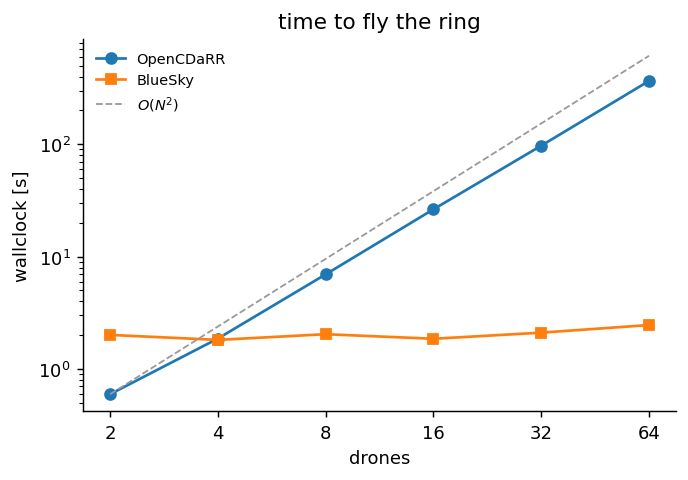

In [7]:
ns = np.array(FLEET_SIZES, dtype=float)
w_ours = np.array([ours[n]["wall"] for n in FLEET_SIZES])
w_bsky = np.array([bsky[n]["wall"] for n in FLEET_SIZES])

fig, ax = plt.subplots(figsize=(5.4, 3.8))
ax.plot(ns, w_ours, "o-", label="OpenCDaRR")
ax.plot(ns, w_bsky, "s-", label="BlueSky")
ax.plot(ns, w_ours[0] * (ns / ns[0]) ** 2, "--", lw=1, color="0.6", label="$O(N^2)$")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xticks(FLEET_SIZES); ax.set_xticklabels(FLEET_SIZES)
ax.set_xlabel("drones"); ax.set_ylabel("wallclock [s]")
ax.set_title("time to fly the ring")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUT / "wallclock_vs_bluesky.png", dpi=200, bbox_inches="tight")
plt.show()

**Wallclock to fly the ring, 2 to 64 drones.** Ours runs parallel to the dashed `O(N²)` reference —
a little shallower, since fixed overhead still shows at the small end — while BlueSky's is flat: from
2 drones to 64 it barely moves.

BlueSky's `StateBased.detect` builds one `N×N` matrix and runs a dozen elementwise numpy operations
over it. There is no Python loop anywhere in the traffic update, so its per-step time is essentially
fixed framework overhead and a fleet this size never touches it.

Ours pays a Python function call per *pair*, per step. `geo.qdrdist` is reached through
`relative_enu` from four places: the separation measurement (twice per step, for the segment
minimum), the conflict accumulator, the termination test, and the kinematics. That is a clean `N²`.

## What the geodesy costs

Profiling puts about two thirds of our time inside `geo.qdrdist`, and most of that is overhead rather
than arithmetic: the function does its scalar trigonometry through `numpy`, so every `np.sin` of a
single float pays numpy's array-dispatch cost to perform one operation.

Two cheaper spellings are worth measuring:

- **`math`** — the identical formula, in the identical order, through the `math` module, which calls
  the same underlying libm directly. This is **bit-identical**: checked over 200,000 points from ±80°
  latitude and 0.1 m to 500 km, with zero differing results for `earth_radius`, `forward` or
  `qdrdist`. About 12× faster per call.
- **`kwik`** — the equirectangular approximation BlueSky uses, which drops the haversine and the
  `asin` entirely. About 21× faster per call, but it is an **approximation**: roughly 2 mm and 0.02°
  over the separations in this scenario. Cheap, but it changes the answer, and the check below shows
  by how much.

Neither is in the package. Both are patched in at runtime here, so the notebook measures what each
would buy — and prints what each does to the outcome rather than asking you to trust it.

In [8]:
_A, _B = 6378137.0, 6356752.314245
_A2, _B2 = _A * _A, _B * _B


def earth_radius_math(lat_deg):
    lat = math.radians(lat_deg)
    c, s = math.cos(lat), math.sin(lat)
    an, bn, ad, bd = _A2 * c, _B2 * s, _A * c, _B * s
    return math.sqrt((an * an + bn * bn) / (ad * ad + bd * bd))


def qdrdist_math(lat1_deg, lon1_deg, lat2_deg, lon2_deg):
    """geo.qdrdist, same formula and order, through math instead of numpy."""
    radius = earth_radius_math(lat1_deg)
    lat1, lat2 = math.radians(lat1_deg), math.radians(lat2_deg)
    dlat = lat2 - lat1
    dlon = math.radians(lon2_deg - lon1_deg)
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    dist = 2.0 * radius * math.asin(math.sqrt(a))
    y = math.sin(dlon) * math.cos(lat2)
    x = math.cos(lat1) * math.sin(lat2) - math.sin(lat1) * math.cos(lat2) * math.cos(dlon)
    return math.degrees(math.atan2(y, x)) % 360.0, dist


def qdrdist_kwik(lat1_deg, lon1_deg, lat2_deg, lon2_deg):
    """Equirectangular: flat-earth offsets about the midpoint latitude. No haversine, no asin."""
    latm = 0.5 * (lat1_deg + lat2_deg)
    dlat = math.radians(lat2_deg - lat1_deg)
    dlon = math.radians(lon2_deg - lon1_deg) * math.cos(math.radians(latm))
    return math.degrees(math.atan2(dlon, dlat)) % 360.0, earth_radius_math(latm) * math.hypot(
        dlat, dlon)


def forward_math(lat_deg, lon_deg, bearing_deg, dist_m):
    radius = earth_radius_math(lat_deg)
    lat1, lon1 = math.radians(lat_deg), math.radians(lon_deg)
    bearing, ang = math.radians(bearing_deg), dist_m / radius
    lat2 = math.asin(math.sin(lat1) * math.cos(ang)
                     + math.cos(lat1) * math.sin(ang) * math.cos(bearing))
    lon2 = lon1 + math.atan2(math.sin(bearing) * math.sin(ang) * math.cos(lat1),
                             math.cos(ang) - math.sin(lat1) * math.sin(lat2))
    return math.degrees(lat2), math.degrees(lon2)


@contextlib.contextmanager
def geodesy(qdrdist_fn):
    """Swap geo's functions for the duration of the block. kwik varies only the inverse solve."""
    saved = (geo.earth_radius, geo.qdrdist, geo.forward)
    geo.earth_radius, geo.qdrdist, geo.forward = earth_radius_math, qdrdist_fn, forward_math
    try:
        yield
    finally:
        geo.earth_radius, geo.qdrdist, geo.forward = saved


def benchmark_with(label, qdrdist_fn):
    rows = []
    for n in FLEET_SIZES:
        for rep in range(reps_for(n)):
            started = datetime.now().astimezone()
            with geodesy(qdrdist_fn):
                wall, sim_t, steps, _ = fly_ours(scenario["fleets"][str(n)])
            rows.append({"n": n, "rep": rep, "started": started.isoformat(timespec="seconds"),
                         "wallclock_s": wall, "sim_t_s": sim_t, "steps": steps})
            print(f"{label:6} n={n:2d} rep {rep}  sim={sim_t:6.2f}s  wall={wall:8.2f}s",
                  flush=True)
    return rows


results_math = benchmark_with("math", qdrdist_math)
results_kwik = benchmark_with("kwik", qdrdist_kwik)
(OUT / "results_math.json").write_text(json.dumps(results_math, indent=1))
(OUT / "results_kwik.json").write_text(json.dumps(results_kwik, indent=1))

# what each one does to the answer -- run on the small fleets, where a repeat is cheap
print()
for n in [2, 4, 8]:
    _, _, _, base = fly_ours(scenario["fleets"][str(n)])
    with geodesy(qdrdist_math):
        _, _, _, m = fly_ours(scenario["fleets"][str(n)])
    with geodesy(qdrdist_kwik):
        _, _, _, k = fly_ours(scenario["fleets"][str(n)])
    print(f"n={n:2d}  math identical: {m.min_sep == base.min_sep}"
          f"   kwik identical: {k.min_sep == base.min_sep}"
          f"   |  min_sep {base.min_sep:.6e} / {m.min_sep:.6e} / {k.min_sep:.6e}")

math   n= 2 rep 0  sim=297.05s  wall=    0.16s


math   n= 2 rep 1  sim=297.05s  wall=    0.18s


math   n= 2 rep 2  sim=297.05s  wall=    0.17s


math   n= 4 rep 0  sim=297.05s  wall=    0.45s


math   n= 4 rep 1  sim=297.05s  wall=    0.40s


...

kwik   n=32 rep 1  sim=297.05s  wall=   14.80s


kwik   n=64 rep 0  sim=297.05s  wall=   53.28s


n= 2  math identical: True   kwik identical: False   |  min_sep 9.208718e-24 / 9.208718e-24 / 9.192046e-24


n= 4  math identical: True   kwik identical: False   |  min_sep 9.208718e-24 / 9.208718e-24 / 9.192046e-24


n= 8  math identical: True   kwik identical: False   |  min_sep 9.208718e-24 / 9.208718e-24 / 9.192046e-24


In [9]:
fast_math, fast_kwik = summarise(results_math), summarise(results_kwik)

print(f"{'n':>3} {'numpy':>10} {'math':>10} {'kwik':>10} {'BlueSky':>10} "
      f"{'math/numpy':>11} {'kwik/numpy':>11} {'kwik vs BS':>11}")
for n in FLEET_SIZES:
    o, m, k, b = ours[n], fast_math[n], fast_kwik[n], bsky[n]
    print(f"{n:>3} {o['wall']:>9.2f}s {m['wall']:>9.2f}s {k['wall']:>9.2f}s {b['wall']:>9.2f}s "
          f"{o['wall'] / m['wall']:>10.2f}x {o['wall'] / k['wall']:>10.2f}x "
          f"{k['wall'] / b['wall']:>10.2f}x")

  n      numpy       math       kwik    BlueSky  math/numpy  kwik/numpy  kwik vs BS
  2      0.60s      0.17s      0.14s      2.01s       3.49x       4.19x       0.07x
  4      1.87s      0.41s      0.37s      1.82s       4.59x       5.03x       0.20x
  8      6.96s      1.32s      1.09s      2.04s       5.29x       6.39x       0.53x
 16     26.36s      4.90s      4.00s      1.86s       5.38x       6.59x       2.15x
 32     97.02s     16.91s     15.09s      2.11s       5.74x       6.43x       7.16x
 64    365.49s     63.83s     53.28s      2.46s       5.73x       6.86x      21.63x


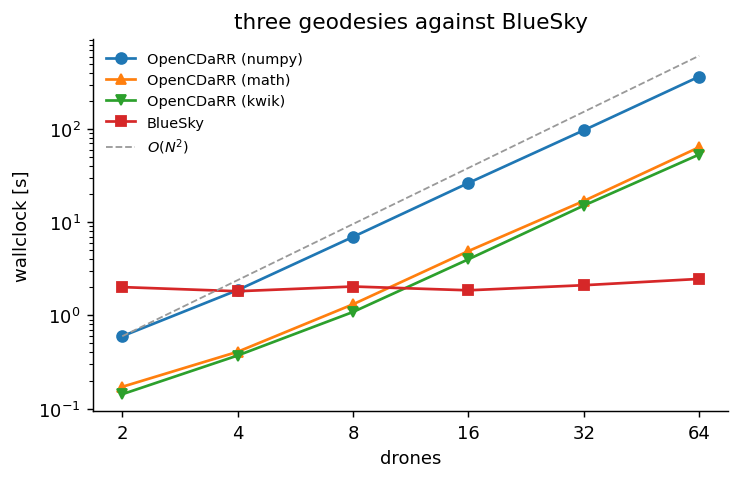

In [10]:
w_math = np.array([fast_math[n]["wall"] for n in FLEET_SIZES])
w_kwik = np.array([fast_kwik[n]["wall"] for n in FLEET_SIZES])

fig, ax = plt.subplots(figsize=(5.8, 3.8))
ax.plot(ns, w_ours, "o-", label="OpenCDaRR (numpy)")
ax.plot(ns, w_math, "^-", label="OpenCDaRR (math)")
ax.plot(ns, w_kwik, "v-", label="OpenCDaRR (kwik)")
ax.plot(ns, w_bsky, "s-", label="BlueSky")
ax.plot(ns, w_ours[0] * (ns / ns[0]) ** 2, "--", lw=1, color="0.6", label="$O(N^2)$")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xticks(FLEET_SIZES); ax.set_xticklabels(FLEET_SIZES)
ax.set_xlabel("drones"); ax.set_ylabel("wallclock [s]")
ax.set_title("three geodesies against BlueSky")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUT / "geodesy_variants.png", dpi=200, bbox_inches="tight")
plt.show()

**The same benchmark with three geodesies.** All three of our curves are parallel: swapping the
geodesy shifts the line down bodily and leaves its slope alone. That is what a constant factor does
to a quadratic — it buys fleet size, it does not change the shape. BlueSky stays flat throughout.

## Reading these numbers honestly

- **A constant factor is not a fix.** `math` is worth roughly 5× and `kwik` a little more, which
  moves the crossover with BlueSky out by two to three doublings of fleet size. Past that the `N²`
  term is back in charge. Closing the gap properly means computing the pairwise geometry in one
  vectorised pass, the way BlueSky does.
- **`math` is free; `kwik` is not.** `math` returns the same bits, so it costs nothing but the edit.
  `kwik` is an approximation, and the check above shows what it does to `min_sep` — worth having in
  hand, but it is a modelling decision, not a speed knob.
- **Detection cadence is not matched.** BlueSky detects on `asas_dt = 1 s`; we detect every step.
  Gating our accumulator to the same 1 Hz cadence recovers about 25% at `N = 16` — real, but it
  leaves the `N²` shape untouched, because detection is only about a fifth of the cost. The
  separation measurement is over half of it.
- **Part of our cost buys something BlueSky does not offer.** The twice-per-step pairwise geometry
  feeds `segment_min_range`, which measures the closest approach *across* each step rather than at
  its endpoints. Endpoint sampling reports too much separation, and the error grows as the radius
  tightens — which is exactly where a rare-event estimator does its work. BlueSky does not measure
  this at all.
- **The estimators do not run this workload.** Every plain-MC encounter and every IPS particle is two
  aircraft, where there is exactly one pair. That is the far left of these plots, where we are
  already well ahead — so this benchmark measures the fleet path, not the path the numbers in the
  paper come from.
- **Single process, no parallelism**, on one machine. `opencdarr.parallel` distributes *encounters*
  across workers, not aircraft within one; neither side is using it here.